# NOAH-MP Causal Discovery Dataset
Load all sites, check autocorrelation, subsample to i.i.d. rows, save final dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.stattools import acf

SITES_DIR = Path('/Net/Groups/BGI/work_1/scratch/npapan/LLM_causal_discovery/NOAH_MP/sites')
OUT_DIR   = Path('/Net/Groups/BGI/work_1/scratch/npapan/LLM_causal_discovery/NOAH_MP')

SITE_NAMES = {
    0: 'Madagascar', 1: 'Amazon',      2: 'Congo',      3: 'Sahel',
    4: 'Germany',    5: 'BoealCanada', 6: 'GreatPlains', 7: 'SpainMed',
    8: 'IndiaDeccan', 9: 'Australia',
}

## 1. Load all sites

In [2]:
obs_frames = []
hid_frames = []

for site_id in range(10):
    site_dir = SITES_DIR / f'site_{site_id}'
    obs_f = site_dir / 'observed.csv'
    hid_f = site_dir / 'hidden.csv'
    if not obs_f.exists():
        print(f'  site_{site_id}: missing observed.csv — skipping')
        continue
    obs = pd.read_csv(obs_f, parse_dates=['timestamp'])
    hid = pd.read_csv(hid_f, parse_dates=['timestamp'])
    obs_frames.append(obs)
    hid_frames.append(hid)
    print(f'  site_{site_id} ({SITE_NAMES[site_id]}): {len(obs)} rows')

obs_all = pd.concat(obs_frames, ignore_index=True)
hid_all = pd.concat(hid_frames, ignore_index=True)
print(f'\nTotal rows: {len(obs_all)}')
print('Columns:', obs_all.columns.tolist())

  site_0 (Madagascar): 17543 rows
  site_1 (Amazon): 17543 rows


  site_2 (Congo): 17543 rows
  site_3 (Sahel): 17543 rows


  site_4 (Germany): 17543 rows
  site_5 (BoealCanada): 17543 rows


  site_6 (GreatPlains): 17543 rows
  site_7 (SpainMed): 17543 rows


  site_8 (IndiaDeccan): 17543 rows
  site_9 (Australia): 17543 rows

Total rows: 175430
Columns: ['timestamp', 'site_id', 'site_name', 'lat', 'lon', 'Tair', 'Ur', 'SWdown', 'LWdown', 'Precip', 'Rn', 'LAI', 'Et', 'Eg', 'H', 'LE', 'SWC']


## 2. Deseasonalize

Subtract mean per (hour-of-day × month) from each variable. Removes diurnal + annual cycles.
Residuals reflect synoptic/event-scale variability — the right scale for causal discovery.

In [3]:
DESEASON_VARS = ['Tair', 'Ur', 'SWdown', 'LWdown', 'Precip', 'Rn', 'LAI', 'Et', 'Eg', 'H', 'LE', 'SWC']

obs_frames_raw = list(obs_frames)  # keep originals for reference
obs_frames = []

for obs_raw in obs_frames_raw:
    obs = obs_raw.copy()
    obs['_hour']  = obs['timestamp'].dt.hour
    obs['_month'] = obs['timestamp'].dt.month

    # Subtract climatological mean per (hour, month) — removes diurnal + seasonal cycles
    clim = obs.groupby(['_hour', '_month'])[DESEASON_VARS].transform('mean')
    obs[DESEASON_VARS] = obs[DESEASON_VARS] - clim

    obs = obs.drop(columns=['_hour', '_month'])
    obs_frames.append(obs)
    print(f"  {obs['site_name'].iloc[0]}: deseasonalized")

print('\nobs_frames now contains anomalies (raw − hourly×monthly climatology).')


  Madagascar: deseasonalized
  Amazon: deseasonalized
  Congo: deseasonalized


  Sahel: deseasonalized
  Germany: deseasonalized
  BoealCanada: deseasonalized
  GreatPlains: deseasonalized
  SpainMed: deseasonalized
  IndiaDeccan: deseasonalized
  Australia: deseasonalized

obs_frames now contains anomalies (raw − hourly×monthly climatology).


## 2. ACF analysis — find minimum decorrelation lag

In [4]:
from scipy.signal import find_peaks

ACF_THRESHOLD = 0.1
MAX_LAGS      = 720   # hours (30 days)
HARD_CAP      = 240   # hours (10 days) — cap if envelope never drops below threshold
INTERVAL_CAP  = 240   # hours (10 days) — hard cap on subsampling interval

CAUSAL_VARS = ['Tair', 'Ur', 'SWdown', 'LWdown', 'Precip', 'Rn', 'LAI', 'Et', 'Eg', 'H', 'LE', 'SWC']

def envelope_decorr_lag(acf_vals, threshold=ACF_THRESHOLD, hard_cap=HARD_CAP):
    """Lag where ACF envelope (local maxima of |ACF|) first drops below threshold.
    Avoids false early crossings from oscillatory signals (e.g. diurnal Tair)."""
    abs_acf = np.abs(acf_vals)
    peaks, _ = find_peaks(abs_acf)
    if len(peaks) == 0:
        below = np.where(abs_acf < threshold)[0]
        return int(below[0]) if len(below) > 0 else hard_cap
    below_peaks = peaks[abs_acf[peaks] < threshold]
    return int(below_peaks[0]) if len(below_peaks) > 0 else hard_cap

lag_records = []

for obs in obs_frames:
    site_id   = int(obs['site_id'].iloc[0])
    site_name = obs['site_name'].iloc[0]
    row = {'site': site_name}
    for var in CAUSAL_VARS:
        vals     = obs[var].dropna().values
        acf_vals = acf(vals, nlags=MAX_LAGS, fft=True)
        row[var] = envelope_decorr_lag(acf_vals)
    lag_records.append(row)

lag_df = pd.DataFrame(lag_records).set_index('site')
lag_df.loc['MAX'] = lag_df.max()

print(f'Decorrelation lag (hours) via ACF envelope  [cap={HARD_CAP}h]:')
print(lag_df.to_string())

non_swc_max = lag_df.loc['MAX', [v for v in CAUSAL_VARS if v != 'SWC']].max()
print(f'\nMax lag excl. SWC: {int(non_swc_max)}h  →  capped at {INTERVAL_CAP}h')

SUBSAMPLE_INTERVAL = min(int(non_swc_max), INTERVAL_CAP)
print(f'SUBSAMPLE_INTERVAL = {SUBSAMPLE_INTERVAL}h')
print(f'Expected rows per site: ~{17543 // SUBSAMPLE_INTERVAL}  →  total ~{10 * 17543 // SUBSAMPLE_INTERVAL}')


/User/homes/npapan/miniforge3/envs/ml_basic/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


Decorrelation lag (hours) via ACF envelope  [cap=240h]:
             Tair   Ur  SWdown  LWdown  Precip  Rn  LAI   Et   Eg   H   LE  SWC
site                                                                           
Madagascar    128   60       2      69      33  11  240   53  216  60   85  240
Amazon        251   39      11      59      11  10    3   48  107  10   10  240
Congo          75   24       6      40      20  10    3   28   83  13   15  240
Sahel         163   87       2     161      19  11  240  229  240  12  181  240
Germany       210  108      13     103      19  35  240   73   71  69   73  240
BoealCanada   260   59      47     115      23  12  240   70   73  12   61  503
GreatPlains   309   75      59     108      19  35  240   10   74  12   94  459
SpainMed      156   73       2     149      29  34  240    7  255  12  204  414
IndiaDeccan   146  107       4     114      28  35  240   84  190  62  133  528
Australia     147   40       2     126      23  58  240   35  40

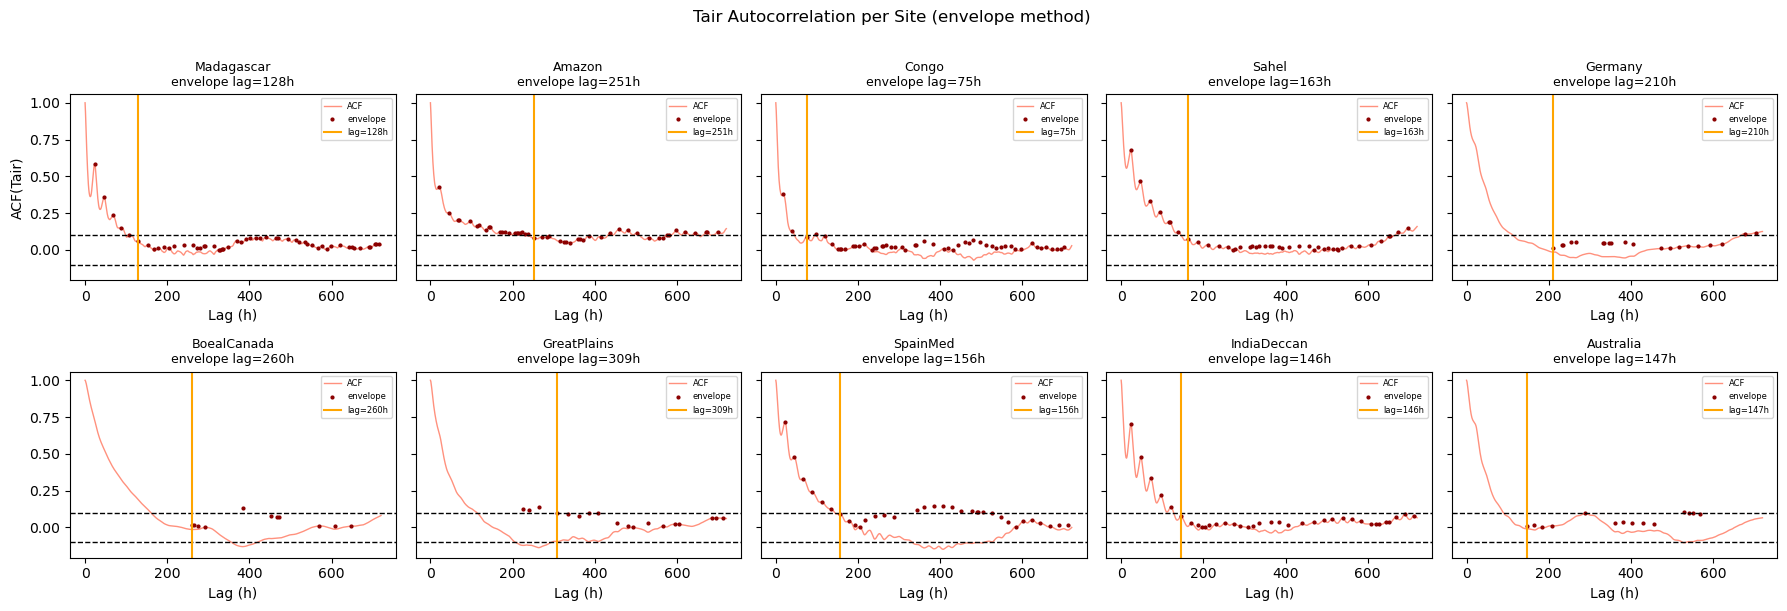

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6), sharey=True)
axes = axes.flatten()

for i, obs in enumerate(obs_frames):
    site_name = obs['site_name'].iloc[0]
    tair      = obs['Tair'].dropna().values
    acf_vals  = acf(tair, nlags=MAX_LAGS, fft=True)
    lag       = envelope_decorr_lag(acf_vals)

    # Plot raw ACF + envelope (peaks)
    abs_acf = np.abs(acf_vals)
    peaks, _ = find_peaks(abs_acf)

    ax = axes[i]
    ax.plot(acf_vals, color='tomato', lw=1, alpha=0.7, label='ACF')
    ax.plot(peaks, abs_acf[peaks], 'o', color='darkred', ms=2, label='envelope')
    ax.axhline( ACF_THRESHOLD, color='k', lw=1, ls='--')
    ax.axhline(-ACF_THRESHOLD, color='k', lw=1, ls='--')
    ax.axvline(lag, color='orange', lw=1.5, label=f'lag={lag}h')
    ax.set_title(f'{site_name}\nenvelope lag={lag}h', fontsize=9)
    ax.set_xlabel('Lag (h)')
    if i == 0:
        ax.set_ylabel('ACF(Tair)')
    ax.legend(fontsize=6)

plt.suptitle('Tair Autocorrelation per Site (envelope method)', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'acf_tair.png', dpi=120, bbox_inches='tight')
plt.show()


## 3. Subsample each site independently

In [6]:
# Override here if you want a different interval
SUBSAMPLE_INTERVAL = 240

obs_sub_frames = []
hid_sub_frames = []

for obs, hid in zip(obs_frames, hid_frames):
    site_id   = int(obs['site_id'].iloc[0])
    site_name = obs['site_name'].iloc[0]

    # Drop NaN rows, then subsample every SUBSAMPLE_INTERVAL rows
    obs_clean = obs.dropna().reset_index(drop=True)
    hid_clean = hid.set_index('timestamp').reindex(obs_clean['timestamp']).reset_index()

    obs_s = obs_clean.iloc[::SUBSAMPLE_INTERVAL].reset_index(drop=True)
    hid_s = hid_clean.iloc[::SUBSAMPLE_INTERVAL].reset_index(drop=True)

    obs_sub_frames.append(obs_s)
    hid_sub_frames.append(hid_s)
    print(f'  site_{site_id} ({site_name}): {len(obs_s)} subsampled rows')

obs_final = pd.concat(obs_sub_frames, ignore_index=True)
hid_final = pd.concat(hid_sub_frames, ignore_index=True)
print(f'\nTotal subsampled rows: {len(obs_final)}  (n = {len(obs_final)})')

  site_0 (Madagascar): 74 subsampled rows
  site_1 (Amazon): 74 subsampled rows
  site_2 (Congo): 74 subsampled rows
  site_3 (Sahel): 74 subsampled rows
  site_4 (Germany): 74 subsampled rows
  site_5 (BoealCanada): 74 subsampled rows
  site_6 (GreatPlains): 74 subsampled rows
  site_7 (SpainMed): 74 subsampled rows
  site_8 (IndiaDeccan): 74 subsampled rows
  site_9 (Australia): 74 subsampled rows

Total subsampled rows: 740  (n = 740)


## 4. Basic statistics

In [7]:
causal_vars = ['Tair', 'Ur', 'SWdown', 'LWdown', 'Precip', 'Rn', 'LAI', 'Et', 'Eg', 'H', 'LE', 'SWC']
print(obs_final[causal_vars].describe().round(4).to_string())
print('\nMissing values per column:')
print(obs_final[causal_vars].isna().sum())

           Tair        Ur    SWdown    LWdown    Precip        Rn       LAI     Et     Eg         H        LE       SWC
count  740.0000  740.0000  740.0000  740.0000  740.0000  740.0000  740.0000  740.0  740.0  740.0000  740.0000  740.0000
mean     0.0633    0.0415   -0.0197    0.7802    0.0000    0.4215    0.0044   -0.0    0.0    1.1161    0.3362   -0.0006
std      3.2967    1.0832   41.7491   24.7704    0.0002   27.5586    0.1638    0.0    0.0   23.8074   10.9145    0.0289
min    -18.7363   -3.3163 -374.9229  -93.6966   -0.0001 -203.0828   -0.7035   -0.0   -0.0 -151.8143  -48.6224   -0.0991
25%     -1.2935   -0.5111    0.0000  -12.9244   -0.0000   -9.1091   -0.0206   -0.0   -0.0   -4.2245   -3.3872   -0.0144
50%      0.0855   -0.0208    0.0000   -0.3321   -0.0000   -0.2402    0.0000   -0.0   -0.0    0.6420   -0.5589   -0.0015
75%      1.4676    0.4294    0.0000   13.7973   -0.0000   10.1329    0.0310    0.0    0.0    6.0282    2.0553    0.0108
max     14.2112    5.9031  161.5142  102

## 5. NOAH-MP Process Equations for Observed Variables

Source: Yang et al. (2023) *Technical Description of Noah-MP v5.0*, NCAR Technical Note NCAR/TN-599+STR.

---

### Variables tracked in `causal_observed.csv`

**Metadata (not used in causal graph):**

| Column | Description |
|--------|-------------|
| `timestamp` | Hourly UTC timestamp |
| `site_id` | Site index 0–9 |
| `site_name` | Site name (Madagascar, Amazon, …) |
| `lat`, `lon` | Geographic coordinates |

**Forcing inputs** (prescribed from ERA5 — causally exogenous):

| Column | Symbol | Units | Description |
|--------|--------|-------|-------------|
| `Tair` | $T_{air}$ | K | Near-surface air temperature |
| `Ur` | $U_r$ | m/s | Wind speed at reference height |
| `SWdown` | $S_{\downarrow}$ | W/m² | Downward shortwave (solar) radiation |
| `LWdown` | $L_{\downarrow}$ | W/m² | Downward longwave radiation |
| `Precip` | $P$ | mm/s | Total precipitation (rain + snow) |

**NOAH-MP model outputs** (computed by the model — causally endogenous):

| Column | Symbol | Units | Description |
|--------|--------|-------|-------------|
| `Rn` | $R_n$ | W/m² | Net radiation at surface |
| `LAI` | LAI | m²/m² | Leaf area index |
| `H` | $H$ | W/m² | Sensible heat flux |
| `Et` | $E_t$ | W/m² | Transpiration (vegetation) |
| `Eg` | $E_g$ | W/m² | Ground evaporation |
| `LE` | $LE$ | W/m² | Latent heat flux ($= \lambda_v(E_t + E_g)$) |
| `SWC` | $\theta_{soil}$ | m³/m³ | Soil water content (volumetric, column mean) |

**Hidden variables tracked separately in `causal_hidden.csv`** (mediate causal paths but not observable):

| Column | Symbol | Description |
|--------|--------|-------------|
| `Tv_hidden` | $T_v$ | Canopy/vegetation temperature — mediates $R_n, T_{air}, U_r \to H$ |
| `rb_hidden` | $r_b$ | Leaf boundary layer aerodynamic resistance — mediates $U_r, LAI \to E_t, H$ |
| `Wc_hidden` | $W_c$ | Canopy intercepted water — mediates $Precip \to E_t$ |

Note: $\beta$ (soil moisture stress factor) and $r_{surf}$ (soil surface resistance) are additional hidden mediators computed internally by NOAH-MP but not saved to output files.

---

### Process Equations

---

### Net Radiation: $R_n$ — §3.6.6, §3.6.15

$$R_n = S_{abs,sfc} + L_{net,sfc}$$

Shortwave absorbed by surface (canopy + ground, Eq. 3.6.129, 3.6.132–133):
$$S_{abs,sfc} = \underbrace{S_{\downarrow,dir}\cdot f_{abd} + S_{\downarrow,dif}\cdot f_{abi}}_{S_{abs,veg}} + \underbrace{T_d(1-\alpha_{dir}) + T_i(1-\alpha_{dif})}_{S_{abs,grd}}$$

where $f_{abd},f_{abi}$ are canopy absorption fractions from the two-stream scheme (function of **LAI**), and $\alpha$ is surface albedo (also depends on **LAI**).

Net longwave (Eq. 3.6.416):
$$L_{net,sfc} = \varepsilon_{sfc}\,L_{\downarrow} - \varepsilon_{sfc}\,\sigma\,T_{sfc}^4, \qquad \varepsilon_{sfc} = f(LAI)$$

**Causal parents of $R_n$:** SWdown, LWdown, LAI (via $\alpha$ and $\varepsilon_{sfc}$)

---

### Sensible Heat: $H$ — §3.6.11–3.6.14

Energy balance at canopy level (Eq. 3.6.165):
$$S_{abs,can} + H_{pr,can} = L_{net,can} + H_S + \lambda E_{tr} + \Delta H_{s,can}$$

Sensible heat from canopy via aerodynamic/boundary-layer resistance (Eq. 3.6.165–3.6.240):
$$H_S = \rho C_p \frac{T_v - T_{air}}{r_b}$$

where $T_v$ (canopy temperature, **hidden**) is solved by Newton-Raphson iteration; $r_b$ (**hidden** leaf boundary layer resistance) depends on **$U_r$** and canopy structure (**LAI**).

Grid mean (tiled veg + bare, Eq. 3.6.412–413):
$$H = f_{veg}\,H_{veg} + (1-f_{veg})\,H_{bare}$$

**Causal parents of $H$:** $R_n$, $T_{air}$, $U_r$, LAI → via hidden $T_v$, $r_b$

---

### Transpiration: $E_t$ — §3.6.11, §3.6.8

$$E_t = f_{veg} \cdot LAI \cdot \frac{\rho\,[e_{sat}(T_v) - e_a]}{r_b + r_s}$$

Stomatal resistance $r_s$ (Ball-Berry scheme) depends on **SWdown** (PAR → photosynthesis) and **$T_{air}$**.

Soil moisture transpiration factor $\beta$ (**hidden**, Eq. 3.6.8):
$$\beta = \sum_i f_{root,i}\;\frac{\theta_{soil,i} - \theta_{wilt}}{\theta_{ref} - \theta_{wilt}}, \qquad \theta_{soil} = \textbf{SWC}$$

$r_s \propto 1/\beta$ — dry soil (low **SWC**) increases stomatal resistance and reduces $E_t$.

**Causal parents of $E_t$:** $T_{air}$, $U_r$, LAI, SWC → via hidden $r_b$, $\beta$, $r_s$, $T_v$

---

### Ground Evaporation: $E_g$ — §3.6.11–3.6.12, §3.6.9

$$E_g = \frac{\rho\,[e_{sat}(T_g) - e_a]}{r_{surf} + r_{soil,a}}$$

Soil surface resistance $r_{surf}$ (**hidden**, Eq. 3.6.9):
$$r_{surf} = \exp\!\left(8.25 - 4.225\;\frac{\theta_{soil,1}}{\theta_{sat}}\right), \qquad \theta_{soil,1} = \textbf{SWC (top layer)}$$

Sub-canopy aerodynamic resistance $r_{soil,a}$ depends on **$U_r$**.

**Causal parents of $E_g$:** $U_r$, SWC → via hidden $r_{surf}$, $r_{soil,a}$

---

### Latent Heat: $LE$ — §3.6.14

$$LE = \lambda_v\,(E_t + E_g)$$

$\lambda_v$ = latent heat of vaporization (or sublimation below freezing). Direct sum of transpiration and ground evaporation.

**Causal parents of $LE$:** $E_t$, $E_g$

---

### Leaf Area Index: $LAI$ — §3.3

Static mode (`OptDynamicVeg=4`, default): monthly look-up table, snow burial correction:
$$ELAI = LAI_{table}(month) \times (1 - f_b)$$

Dynamic vegetation mode: LAI from carbon balance, driven by growing degree days (**$T_{air}$**) and soil moisture stress (**SWC**):
$$f_{veg} = 1 - e^{-0.52\,(LAI+SAI)} \quad \text{(Eq. 3.3.10)}$$

**Causal parents of $LAI$:** $T_{air}$, SWC (dynamic veg); prescribed (static)

---

### Soil Water Content: $\theta_{soil}$ = SWC — §3.7.8.3

Richards equation solved implicitly per soil layer (Eq. 3.7.252):

$$\frac{\partial\theta}{\partial t} = \frac{\partial}{\partial z}\!\left[\lambda_{soil}\frac{\partial\theta}{\partial z} + K_{hyd}\right] - Q_{transp} - Q_{evap}$$

Discretised excess-water flux at top layer $i=1$:
$$Q_{diff,1} = \lambda_{soil}\,G_\theta + K_{hyd} - \underbrace{Q_{infil}}_{\propto\,\textbf{Precip}} + \underbrace{Q_{transp}}_{\propto\,\textbf{Et}} + \underbrace{Q_{evap}}_{\propto\,\textbf{Eg}}$$

Final update (Eq. 3.7.266, 3.7.290):
$$\theta_{soil} = W_{liq,soil} + W_{ice,soil}$$

**Causal parents of SWC:** Precip (infiltration), $E_t$ (root water uptake), $E_g$ (surface evaporation)

In [ ]:
# Within-snapshot causal edges from NOAH-MP process equations
# (Yang et al. 2023, NCAR/TN-599+STR)
#
# Each row in causal_observed.csv contains all variables at the same timestep t.
# Valid edges are those where one variable structurally determines another
# within the same timestep computation.
#
# Excluded as cross-timestep (affect next-step state, not same-row value):
#   Precip → SWC  (infiltration updates SWC(t+1))
#   Tair   → LAI  (phenology accumulates over days)
#   SWC    → LAI  (soil moisture stress on growth, lagged)
#   Et     → SWC  (root uptake depletes SWC(t+1))
#   Eg     → SWC  (surface evap depletes SWC(t+1))
#
# SWC and LAI are pre-existing state variables (inputs to this timestep's computation).
# Precip, Tair, Ur, SWdown, LWdown are exogenous ERA5 forcing.

edges = [
    # --- Radiation ---
    ('SWdown', 'Rn'),   # shortwave absorbed by surface (Eq. 3.6.129–3.6.133)
    ('LWdown', 'Rn'),   # net longwave (Eq. 3.6.416)
    ('LAI',    'Rn'),   # surface albedo + emissivity via two-stream scheme (§3.6.5–3.6.7)

    # --- Sensible heat (via hidden Tv, rb) ---
    ('Rn',     'H'),    # energy balance at canopy (Eq. 3.6.165)
    ('Tair',   'H'),    # H = ρCp(Tv − Tair)/rb
    ('Ur',     'H'),    # rb depends on wind speed (§3.6.11)
    ('LAI',    'H'),    # fveg and rb depend on canopy structure

    # --- Transpiration (via hidden rb, β, rs) ---
    ('Tair',   'Et'),   # esat(Tv) and stomatal resistance rs (Ball-Berry, §3.6.11)
    ('Ur',     'Et'),   # leaf boundary-layer resistance rb (§3.6.11)
    ('SWdown', 'Et'),   # PAR → photosynthesis → rs (Ball-Berry)
    ('LAI',    'Et'),   # Et = fveg × LAI × ...
    ('SWC',    'Et'),   # soil moisture stress β = f(θ_soil) (Eq. 3.6.8)

    # --- Ground evaporation (via hidden rsurf, rsoil_a) ---
    ('Rn',     'Eg'),   # ground energy balance → Tg → esat(Tg) (§3.6.12)
    ('Ur',     'Eg'),   # sub-canopy aerodynamic resistance rsoil_a (§3.6.12)
    ('SWC',    'Eg'),   # rsurf = exp(8.25 − 4.225 θ/θ_sat) (Eq. 3.6.9)

    # --- Latent heat ---
    ('Et',     'LE'),   # LE = λv(Et + Eg) (§3.6.14)
    ('Eg',     'LE'),
]

dag_df = pd.DataFrame(edges, columns=['source', 'target'])
print(f'{len(dag_df)} edges:')
print(dag_df.to_string(index=False))


## 6. Save final datasets

In [28]:
obs_final.to_csv(OUT_DIR / 'causal_observed.csv', index=False)
hid_final.to_csv(OUT_DIR / 'causal_hidden.csv',   index=False)
dag_df.to_csv(OUT_DIR    / 'ground_truth_dag.csv', index=False)

print(f'Saved:')
print(f'  causal_observed.csv  — {len(obs_final)} rows x {len(causal_vars)} variables')
print(f'  causal_hidden.csv    — {len(hid_final)} rows x 3 hidden variables')
print(f'  ground_truth_dag.csv — {len(dag_df)} edges')
print(f'  acf_swc.png          — ACF plots')

Saved:
  causal_observed.csv  — 740 rows x 12 variables
  causal_hidden.csv    — 740 rows x 3 hidden variables
  ground_truth_dag.csv — 22 edges
  acf_swc.png          — ACF plots
